In [1]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np

In [2]:
from archs.cnn1 import CNN1
from archs.fc1 import FC1
import pickle 
import torch 
from torch import nn
from environment import CoronagraphEnvironment
import numpy as np

In [3]:
# properties of coronagraph:

NUM_MODES = 10
PIXEL_RESOLUTION = 64
OVERSIZNG_FACTOR = 1
NUM_AIRY=5
CORONAGRAPH_CHARGE = 6
PIXELS_PER_SPACIAL_RES = 2

In [4]:
with open(f"data/V4 gen small_imgs 50000.pkl", 'rb') as f:
    data = pickle.load(f)

difference (should be 0): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


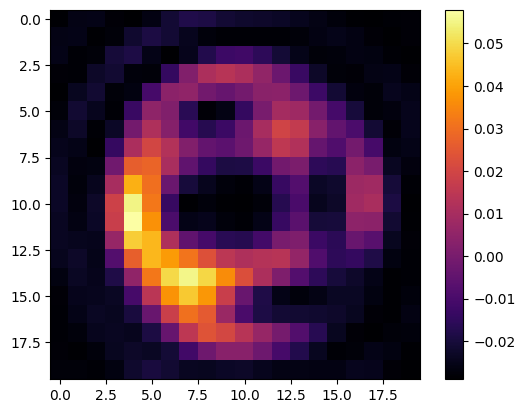

In [5]:
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from skimage.transform import resize

X = np.array(data['images'])
y = np.array(data['dm_settings'])

unnormalized_y0 = y[0]

# normalize y
y_mean = np.mean(y)
y_std_dev = np.std(y)
y = (y - y_mean) / y_std_dev

renormalized_y0 = y[0] * y_std_dev + y_mean 
print(f"difference (should be 0): {unnormalized_y0 - renormalized_y0}")

# normalize x
# X = np.cbrt(X)
X_global_max = np.max(X)
X_global_min = np.min(X)
X_normed = (X - X_global_min) / (X_global_max - X_global_min)
X_global_mean = np.mean(X_normed)
X_normed -= X_global_mean
plt.imshow(X_normed[25][2], cmap='inferno')
plt.colorbar()
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_normed, y, test_size=0.2)

In [7]:
model = FC1(final_output_dim=y_train.shape[1], image_input_shape=X_train.shape[1:])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

X_train_tensor = torch.tensor(X_train, dtype=torch.float)
y_train_tensor = torch.tensor(y_train, dtype=torch.float)


In [8]:
y_test_tensor = torch.tensor(y_test, dtype=torch.float)
X_test_tensor = torch.tensor(X_test, dtype=torch.float)
# img1_train = X_train_tensor[:, 0, :, :].unsqueeze(1)
# img2_train = X_train_tensor[:, 1, :, :].unsqueeze(1)

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# img1_train = img1_train.to(device)
# img2_train = img2_train.to(device)
# list_placeholder = torch.zeros(size=(4000,1)).to(device)
y_train_tensor = y_train_tensor.to(device)
model = model.to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float).to(device)

# img1_test = X_test_tensor[:, 0, :, :].unsqueeze(1).to(device)
# img2_test = X_test_tensor[:, 1, :, :].unsqueeze(1).to(device)

In [113]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
model = model.to(device)

In [114]:
# ...existing code...
epochs = 1000
batch_size = 15000  # lower if you still get OOM
from torch.utils.data import TensorDataset, DataLoader

# create placeholders that match actual dataset sizes
# list_placeholder_train = torch.zeros(len(img1_train), 1)
# list_placeholder_val = torch.zeros(len(img1_test), 1)

# Build CPU datasets and dataloaders (use num_workers=0 in Jupyter/Windows)
train_dataset = TensorDataset(
    X_train_tensor.cpu(),
    # img1_train.cpu(),            # (N_train,1,H,W)
    # img2_train.cpu(),            # (N_train,1,H,W)
    # list_placeholder_train.cpu(),# (N_train,1)
    y_train_tensor.cpu()         # (N_train, n_dm)
)
val_dataset = TensorDataset(
    X_test_tensor.cpu(),
    # img1_test.cpu(),             # (N_val,1,H,W)
    # img2_test.cpu(),             # (N_val,1,H,W)
    # list_placeholder_val.cpu(),  # (N_val,1)
    y_test_tensor.cpu()          # (N_val, n_dm)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

# AMP setup (optional)
# scaler = None
# use_amp = torch.cuda.is_available()
# if use_amp:
#     from torch.cuda.amp import GradScaler, autocast
#     scaler = GradScaler()

# training loop (unchanged)
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for b_imgs, b_y in train_loader:
        # b_img1 = b_img1.to(device, non_blocking=True)
        # b_img2 = b_img2.to(device, non_blocking=True)
        # b_pl = b_pl.to(device, non_blocking=True)
        b_imgs = b_imgs.to(device, non_blocking=True)
        b_y = b_y.to(device, non_blocking=True)

        optimizer.zero_grad()
        # if use_amp:
        #     with autocast():
        #         outputs = model(b_img1, b_img2, b_pl)
        #         loss = criterion(outputs, b_y)
        #     scaler.scale(loss).backward()
        #     scaler.step(optimizer)
        #     scaler.update()
        # else:

        outputs = model(b_imgs)
        loss = criterion(outputs, b_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * b_imgs.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    val_running = 0.0
    with torch.no_grad():
        for v_imgs, v_y in val_loader:
            v_imgs = v_imgs.to(device, non_blocking=True)
            # v_img1 = v_img1.to(device, non_blocking=True)
            # v_img2 = v_img2.to(device, non_blocking=True)
            # v_pl = v_pl.to(device, non_blocking=True)
            v_y = v_y.to(device, non_blocking=True)
            # if use_amp:
            #     with autocast():
            #         v_out = model(v_img1, v_img2, v_pl)
            #         v_loss = criterion(v_out, v_y)
            # else:

            v_out = model(v_imgs)
            v_loss = criterion(v_out, v_y)
            val_running += v_loss.item() * v_imgs.size(0)

    val_loss = val_running / len(val_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
# ...existing code...

Epoch 1/1000, Train Loss: 0.011035, Val Loss: 0.007633
Epoch 2/1000, Train Loss: 0.011124, Val Loss: 0.008921
Epoch 3/1000, Train Loss: 0.006330, Val Loss: 0.006799
Epoch 4/1000, Train Loss: 0.007717, Val Loss: 0.005184
Epoch 5/1000, Train Loss: 0.004467, Val Loss: 0.005743
Epoch 6/1000, Train Loss: 0.005969, Val Loss: 0.004836
Epoch 7/1000, Train Loss: 0.004213, Val Loss: 0.004630
Epoch 8/1000, Train Loss: 0.004837, Val Loss: 0.004233
Epoch 9/1000, Train Loss: 0.003932, Val Loss: 0.004311
Epoch 10/1000, Train Loss: 0.004341, Val Loss: 0.003980
Epoch 11/1000, Train Loss: 0.003806, Val Loss: 0.004101
Epoch 12/1000, Train Loss: 0.004045, Val Loss: 0.003789
Epoch 13/1000, Train Loss: 0.003734, Val Loss: 0.003981
Epoch 14/1000, Train Loss: 0.003867, Val Loss: 0.003732
Epoch 15/1000, Train Loss: 0.003717, Val Loss: 0.003874
Epoch 16/1000, Train Loss: 0.003749, Val Loss: 0.003738
Epoch 17/1000, Train Loss: 0.003719, Val Loss: 0.003777


KeyboardInterrupt: 

In [123]:
y_pred = model(v_imgs[0].unsqueeze(0))
print(f"y_pred = {y_pred}")
actual = v_y[0]
print(f"actual = {actual}")
se = np.linalg.norm(y_pred.cpu().detach().numpy() - actual.cpu().detach().numpy())
print(f"SE = {se}")
print(f"MSE = {se / NUM_MODES}")

y_pred = tensor([[ 0.9837, -1.6971,  1.3731, -0.2838,  0.1044, -0.4273, -1.0968, -1.5067,
          0.8937, -0.2112]], device='cuda:0', grad_fn=<LeakyReluBackward0>)
actual = tensor([ 0.9722, -1.7151,  1.3201, -0.2900,  0.0500, -0.3969, -1.0939, -1.4422,
         0.8970, -0.2136], device='cuda:0')
SE = 0.10663647204637527
MSE = 0.010663647204637527


In [124]:

PATH = "models/V3/small res m1 normed fine-tuned2.pth"  # Choose a suitable path and filename
torch.save(model.state_dict(), PATH)



In [ ]:
model = FC1(final_output_dim=y_train.shape[1], image_input_shape=X_train.shape[1:])
model.load_state_dict(torch.load(PATH))
model.eval()

FC1(
  (final_net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1200, out_features=128, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Linear(in_features=64, out_features=10, bias=True)
    (6): LeakyReLU(negative_slope=0.01)
  )
)

In [130]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float).to(device)

In [131]:
e = CoronagraphEnvironment(
    num_modes=NUM_MODES,
    pixels=PIXEL_RESOLUTION,
    oversizing_factor=OVERSIZNG_FACTOR,
    num_airy=NUM_AIRY,
    coronagraph_charge=CORONAGRAPH_CHARGE,
    pixels_per_spacial_res=PIXELS_PER_SPACIAL_RES
)


initializing coronagraph env. might take a minute.


In [155]:
test_index = 10
dm_proper = (y_test[test_index] * y_std_dev) + y_mean
nudge=[0 for _ in range(NUM_MODES)]
nudge[0] = 3e-7

cpu_model = model.cpu()
print(np.mean(dm_proper) - y_mean)
print(np.mean(y_mean))

-8.462776369379985e-09
1.3766187635025964e-12


In [139]:
y_pred = model(v_imgs[0].cpu().unsqueeze(0))
print(f"y_pred = {y_pred}")
actual = v_y[0]
print(f"actual = {actual}")
se = np.linalg.norm(y_pred.cpu().detach().numpy() - actual.cpu().detach().numpy())
print(f"SE = {se}")
print(f"MSE = {se / NUM_MODES}")

y_pred = tensor([[ 0.9837, -1.6971,  1.3731, -0.2838,  0.1044, -0.4273, -1.0968, -1.5067,
          0.8937, -0.2112]], grad_fn=<LeakyReluBackward0>)
actual = tensor([ 0.9722, -1.7151,  1.3201, -0.2900,  0.0500, -0.3969, -1.0939, -1.4422,
         0.8970, -0.2136], device='cuda:0')
SE = 0.10662984848022461
MSE = 0.010662985034286976


In [56]:
X_test_tensor[1].shape

torch.Size([3, 20, 20])

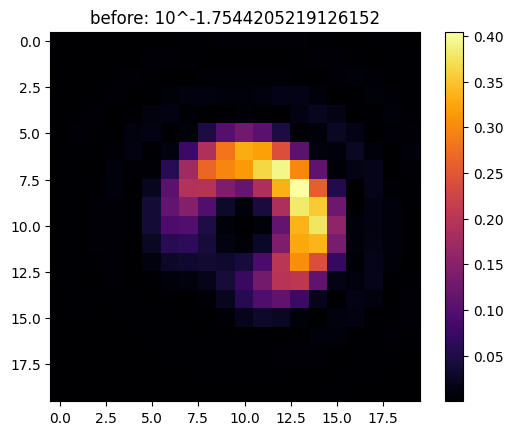

dm_proper: [-2.87034665e-08  5.63067242e-08 -4.69087579e-10  8.49069118e-09
  2.87993173e-08 -2.66810521e-08 -3.91663128e-08 -4.66860433e-08
 -1.57838840e-08 -2.07208840e-08]
y_pred = tensor([[-0.9201,  1.7943, -0.0185,  0.2801,  0.9320, -0.8339, -1.2640, -1.3533,
         -0.4109, -0.6425]])
actual = [-0.90772684  1.78053143 -0.01487738  0.2684557   0.91067085 -0.84377248
 -1.23859109 -1.47638585 -0.49917377 -0.65529542]
SE = 0.15749074886438946
MSE = 0.015749074886438945
actual_setting: [-2.87034665e-08  5.63067242e-08 -4.69087579e-10  8.49069118e-09
  2.87993173e-08 -2.66810521e-08 -3.91663128e-08 -4.66860433e-08
 -1.57838840e-08 -2.07208840e-08]
y prediction: [tensor(2.9096e-08), tensor(-5.6743e-08), tensor(5.8500e-10), tensor(-8.8584e-09), tensor(-2.9473e-08), tensor(2.6369e-08), tensor(3.9971e-08), tensor(4.2792e-08), tensor(1.2993e-08), tensor(2.0315e-08)]


C:\Users\alexe\AppData\Local\Temp\ipykernel_62688\3009849171.py:63: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  se = np.linalg.norm(y_pred - actual)


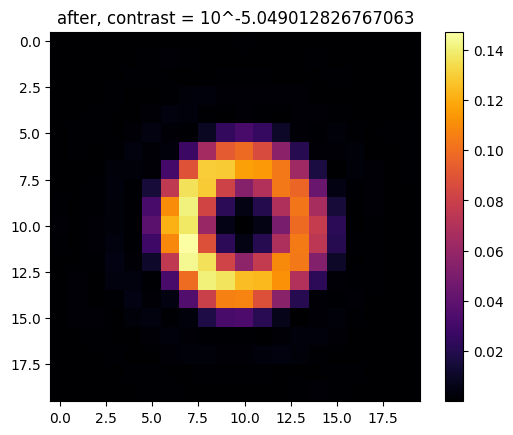

In [ ]:
e.deformable_mirror.flatten()
e.deformable_mirror.actuators = dm_proper

original_setting = e.deformable_mirror.actuators.copy()
cam_img1 = torch.asarray(e.get_camera_image(delta_t=1e-3, noise_enabled=False), dtype=torch.float)
cam_img1 = (cam_img1 - X_global_min) / (X_global_max - X_global_min)

e.deformable_mirror.flatten()
e.deformable_mirror.actuators = original_setting + nudge
cam_img2 = torch.asarray(e.get_camera_image(delta_t=1e-3, noise_enabled=False), dtype=torch.float)
cam_img2 = (cam_img2 - X_global_min) / (X_global_max - X_global_min)

e.deformable_mirror.flatten()
e.deformable_mirror.actuators = original_setting - nudge
cam_img3 = torch.asarray(e.get_camera_image(delta_t=1e-3, noise_enabled=False), dtype=torch.float)
cam_img3 = (cam_img3 - X_global_min) / (X_global_max - X_global_min)


# cam_img1 = torch.asarray(np.log10(1e-15 * e.get_camera_image(delta_t=1e15) + 1), dtype=torch.float)
# cam_img1 = (cam_img1 - X_mean) / X_std
# e.deformable_mirror.actuators += nudge
# cam_img2 = torch.asarray(np.log10(1e-15 * e.get_camera_image(delta_t=1e15) + 1), dtype=torch.float)
# cam_img2 = (cam_img2 - X_mean) / X_std
# e.deformable_mirror.actuators = original_setting

img1 = X_test[test_index][0]
img2 = X_test[test_index][1]
img3 = X_test[test_index][2]



# plt.imshow(img1, cmap='inferno')
# plt.colorbar()
# plt.title(f'before: 10^{np.log10(e.get_contrast())}')
# plt.show()

plt.imshow(cam_img1, cmap='inferno')
plt.colorbar()
plt.title(f'before: 10^{np.log10(e.get_contrast(delta_t=1e15))}')
plt.show()

# plt.imshow(np.array(cam_img3) - np.array(img3), cmap='inferno')
# plt.colorbar()
# plt.title('difference im1')
# plt.show()

# plt.imshow(np.array(cam_img2) - img2, cmap='inferno')
# plt.colorbar()
# plt.title('difference im2')
# plt.show()

print(f"dm_proper: {dm_proper}")
with torch.no_grad():
    merged_imgs = torch.tensor(np.array([cam_img1, cam_img2, cam_img3]), dtype=torch.float).unsqueeze(0)

    y_pred = cpu_model(X_test_tensor[test_index].cpu().unsqueeze(0))
    actual = (dm_proper - y_mean) / y_std_dev 

    print(f"y_pred = {y_pred}")
    print(f"actual = {actual}")
    se = np.linalg.norm(y_pred - actual)
    print(f"SE = {se}")
    print(f"MSE = {se / NUM_MODES}")

    y_pred *= y_std_dev 
    y_pred += y_mean 
    y_pred_list = [-a for a in list(y_pred.cpu()[0])]

    print(f"actual_setting: {original_setting}")
    print(f'y prediction: {y_pred_list}')

e.deformable_mirror.flatten()
e.deformable_mirror.actuators = original_setting + y_pred_list

result_img = e.get_camera_image(delta_t=1e-3, noise_enabled=False)

plt.imshow(result_img, cmap='inferno')
plt.colorbar()
plt.title(f'after, contrast = 10^{np.log10(e.get_contrast(delta_t=1e15))}')
plt.show()

In [173]:
# e.deformable_mirror.flatten()
e.get_contrast(delta_t=1e15)

np.float64(8.932790972464584e-06)

In [ ]:
# TODO
# Make a plot, x axis is noise, y axis is contrast post-processing base case, vs performance of my models.
# In the absesnce of noise, performance of SHWFS = traditional probe. 
# Make an informal write up with equations describing my steps (data generation, estimates for electric field are / infer the electric field from the probes, train a model to predict electric fields given intensity)
# how to train: N pixel image -> 2N dimensional vector, first N are real values and second are imaginary values.
# break up the electric field into parametrized modes. 
# mirror mode vs electric field mode -> complex exponent of the mirror mode.
# infinitely many solutions